In [136]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# ─────────────────────────────────────────────
# CAMINHOS E DADOS
# ─────────────────────────────────────────────
project_root = Path.cwd().resolve()
if not (project_root / "results").exists() and (project_root.parent / "results").exists():
    project_root = project_root.parent

file_resultados = project_root / "results" / "a_20260516_140633" / "summary_a_20260516_140633.csv"
file_baselines  = project_root / "best_solutions" / "best_objectives.csv"

df_resultados = pd.read_csv(file_resultados)
df_baselines  = pd.read_csv(file_baselines)

df_merged = pd.merge(df_resultados, df_baselines, on=["dataset", "instance"], how="inner")
df_merged["pct_best_objective"] = (df_merged["objective_mean"] / df_merged["best_objective"]) * 100

df_grouped = (
    df_merged.groupby("algorithm")
    .agg(
        mean_pct_objective=("pct_best_objective", "mean"),
        sum_exec_time     =("exec_time_mean",      "sum"),
    )
    .reset_index()
)

In [137]:
# ---------------------------------------------------------
# TABELA DE GAP MÉDIO +- DESVIO PADRÃO
# E TEMPO DE EXECUÇÃO +- DESVIO PADRÃO
# ---------------------------------------------------------

# Calcula estatísticas de gap e tempo de execução por algoritmo (média de todas as instâncias)
gap_summary = (
    df_resultados.groupby("algorithm", as_index=False)
    .agg(
        gap_mean_avg=("gap_mean", "mean"),
        gap_std_avg=("gap_std_dev", "std"),
        exec_time_mean_avg=("exec_time_mean", "mean"),
        exec_time_std_avg=("exec_time_std_dev", "std"),
    )
)

# Adiciona IDs aos algoritmos (A1, A2, A3, ...)
gap_summary["id"] = [f"A{i+1}" for i in range(len(gap_summary))]

# Cria tabela formatada
gap_table = pd.DataFrame(
    {
        "ID": gap_summary["id"],
        "Algoritmo": gap_summary["algorithm"],
        "Gap Médio ± Desvio": gap_summary.apply(
            lambda r: f"{r['gap_mean_avg']:.4f} ± {r['gap_std_avg']:.4f}", axis=1
        ),
        "Tempo Execução (s) ± Desvio": gap_summary.apply(
            lambda r: f"{r['exec_time_mean_avg']:.4f} ± {r['exec_time_std_avg']:.4f}", axis=1
        ),
    }
)

# Ordena por gap médio (crescente - melhor primeiro)
gap_table_sorted = gap_table.sort_values(
    by="Gap Médio ± Desvio",
    key=lambda x: x.str.split(" ").str[0].astype(float)
).reset_index(drop=True)

display(gap_table_sorted)

# Opcional: salvar como LaTeX
latex_gap_table = gap_table_sorted.to_latex(
    index=False,
    caption="Gap médio ± desvio padrão e tempo de execução ± desvio padrão por algoritmo",
    label="tab:gap_tempo_algoritmos",
    escape=True,
)

print("\nLaTeX da tabela de gaps e tempos:")
print(latex_gap_table)

,ID,Algoritmo,Gap Médio ± Desvio,Tempo Execução (s) ± Desvio
0,A4,simple_desc_exact,0.6907 ± 0.0000,0.7613 ± 0.1635
1,A5,simple_desc_multi,0.6938 ± 0.0000,0.3749 ± 0.0506
2,A6,simple_desc_simple,0.7017 ± 0.0000,0.1822 ± 0.0194
3,A7,simple_diff_exact_bigger,0.7178 ± 0.0000,0.9244 ± 0.2909
4,A11,simple_diff_multi_bigger,0.7192 ± 0.0000,0.3150 ± 0.0424
5,A8,simple_diff_exact_most_shared,0.7235 ± 0.0000,1.2052 ± 0.2995
6,A12,simple_diff_multi_most_shared,0.7260 ± 0.0000,0.4249 ± 0.0778
7,A34,simple_similar_exact_bigger,0.7287 ± 0.0000,0.7686 ± 0.1827
8,A38,simple_similar_multi_bigger,0.7300 ± 0.0000,0.3060 ± 0.0415
9,A10,simple_diff_exact_smaller,0.7326 ± 0.0000,0.6994 ± 0.0870



LaTeX da tabela de gaps e tempos:
\begin{table}
\caption{Gap médio ± desvio padrão e tempo de execução ± desvio padrão por algoritmo}
\label{tab:gap_tempo_algoritmos}
\begin{tabular}{llll}
\toprule
ID & Algoritmo & Gap Médio ± Desvio & Tempo Execução (s) ± Desvio \\
\midrule
A4 & simple\_desc\_exact & 0.6907 ± 0.0000 & 0.7613 ± 0.1635 \\
A5 & simple\_desc\_multi & 0.6938 ± 0.0000 & 0.3749 ± 0.0506 \\
A6 & simple\_desc\_simple & 0.7017 ± 0.0000 & 0.1822 ± 0.0194 \\
A7 & simple\_diff\_exact\_bigger & 0.7178 ± 0.0000 & 0.9244 ± 0.2909 \\
A11 & simple\_diff\_multi\_bigger & 0.7192 ± 0.0000 & 0.3150 ± 0.0424 \\
A8 & simple\_diff\_exact\_most\_shared & 0.7235 ± 0.0000 & 1.2052 ± 0.2995 \\
A12 & simple\_diff\_multi\_most\_shared & 0.7260 ± 0.0000 & 0.4249 ± 0.0778 \\
A34 & simple\_similar\_exact\_bigger & 0.7287 ± 0.0000 & 0.7686 ± 0.1827 \\
A38 & simple\_similar\_multi\_bigger & 0.7300 ± 0.0000 & 0.3060 ± 0.0415 \\
A10 & simple\_diff\_exact\_smaller & 0.7326 ± 0.0000 & 0.6994 ± 0.0870 \\
A1

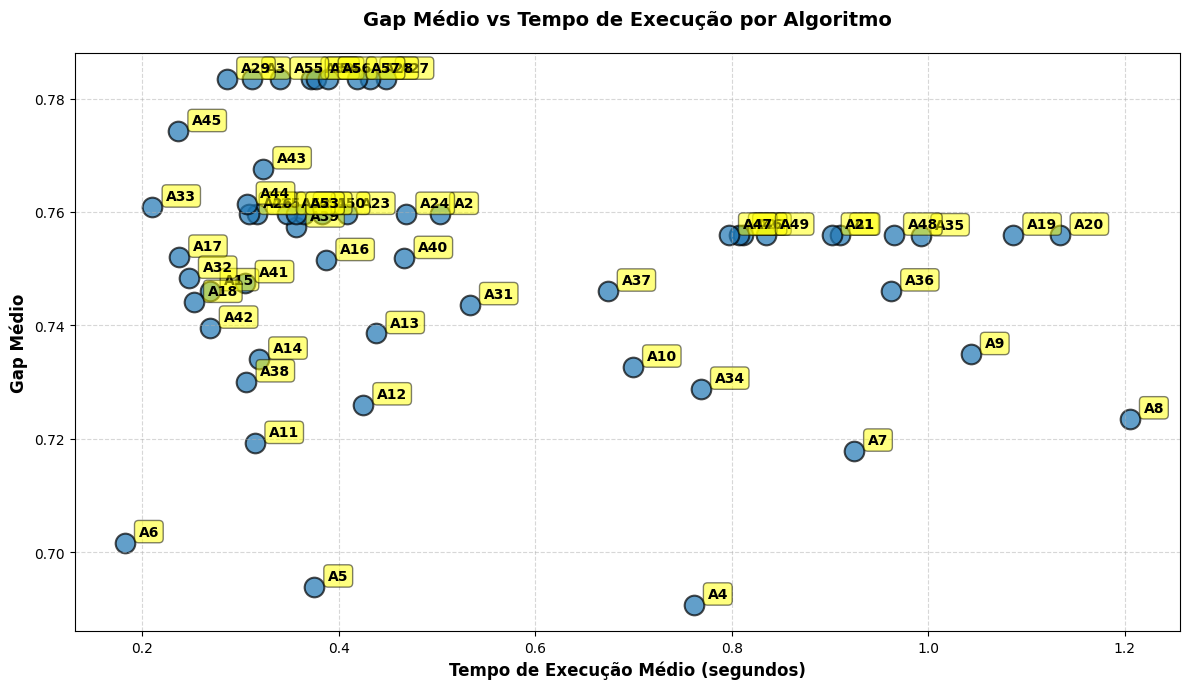

In [138]:
# ---------------------------------------------------------
# GRÁFICO: GAP MÉDIO vs TEMPO DE EXECUÇÃO (com IDs)
# Cores baseadas no parâmetro 'order'
# ---------------------------------------------------------

plt.figure(figsize=(12, 7))

# Plot dos pontos com cores baseadas em order_type
plt.scatter(
    gap_summary["exec_time_mean_avg"],
    gap_summary["gap_mean_avg"],
    s=200,
    alpha=0.7,
    edgecolors="black",
    linewidth=1.5,
)

# Adiciona rótulos com IDs para cada ponto
for idx, row in gap_summary.iterrows():
    plt.annotate(
        row["id"],
        (row["exec_time_mean_avg"], row["gap_mean_avg"]),
        textcoords="offset points",
        xytext=(10, 5),
        ha="left",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5),
    )

# Configurações do gráfico
plt.xlabel("Tempo de Execução Médio (segundos)", fontsize=12, fontweight="bold")
plt.ylabel("Gap Médio", fontsize=12, fontweight="bold")
plt.title(
    "Gap Médio vs Tempo de Execução por Algoritmo",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

# Legenda com cores do order_type
from matplotlib.patches import Patch

# legend_elements = [Patch(facecolor=_VALID_ORDER[order], label=order)
#                    for order in sorted(_VALID_ORDER.keys())]
# legend_elements.append(Patch(facecolor="#7f7f7f", label="Outros"))
# plt.legend(handles=legend_elements, loc="lower right", fontsize=9, title="Order Type", title_fontsize=10)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

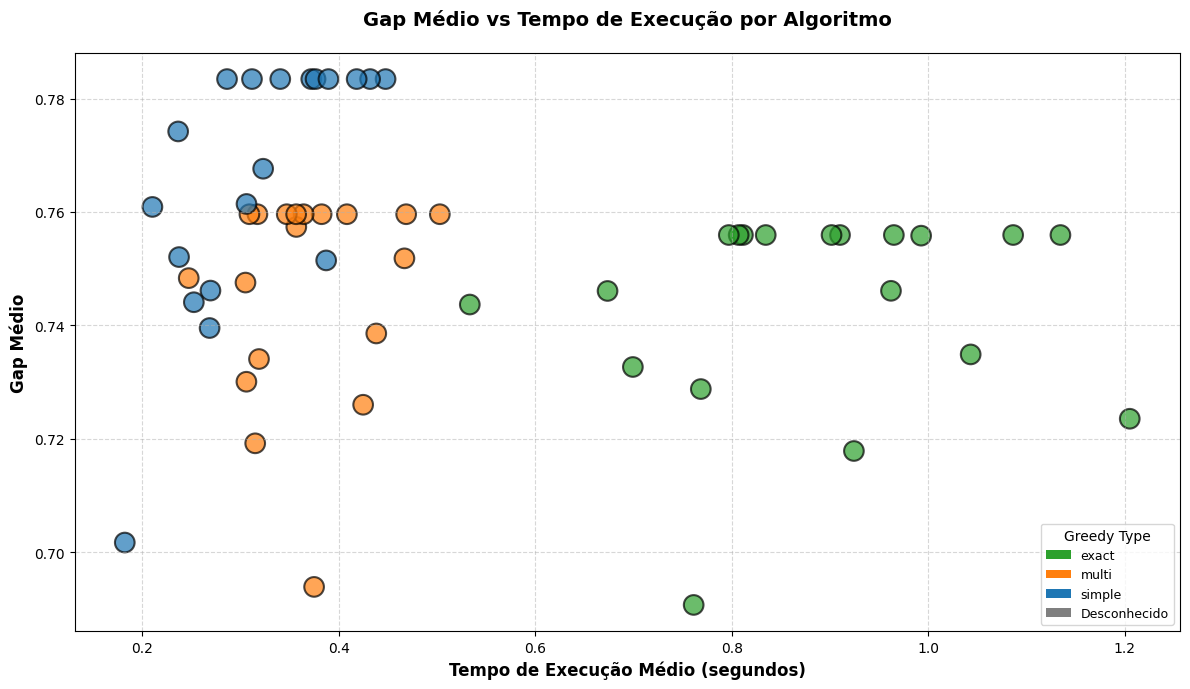

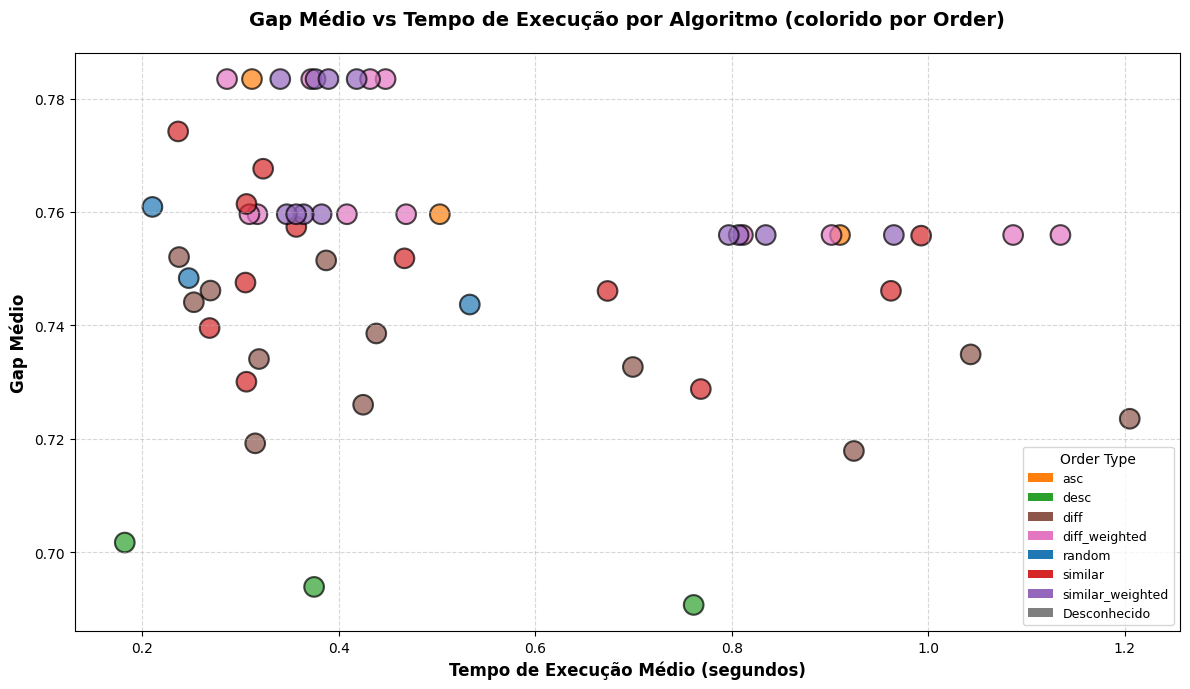

In [139]:
# ---------------------------------------------------------
# GRÁFICO: GAP MÉDIO vs TEMPO DE EXECUÇÃO (sem labels)
# ---------------------------------------------------------

_pal = {"simple": "#1f77b4", "multi": "#ff7f0e", "exact": "#2ca02c"}


def _gtype(name):
    for g in _pal:
        if g in "_".join(name.split("_")[1:]):
            return g
    return None


gap_summary["color"] = gap_summary["algorithm"].apply(
    lambda x: _pal.get(_gtype(x), "#7f7f7f")
)

plt.figure(figsize=(12, 7))

plt.scatter(
    gap_summary["exec_time_mean_avg"],
    gap_summary["gap_mean_avg"],
    s=200,
    alpha=0.7,
    c=gap_summary["color"],
    edgecolors="black",
    linewidth=1.5,
)

plt.xlabel("Tempo de Execução Médio (segundos)", fontsize=12, fontweight="bold")
plt.ylabel("Gap Médio", fontsize=12, fontweight="bold")
plt.title(
    "Gap Médio vs Tempo de Execução por Algoritmo",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=_pal[g], label=g) for g in sorted(_pal)]
legend_elements.append(Patch(facecolor="#7f7f7f", label="Desconhecido"))
plt.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=9,
    title="Greedy Type",
    title_fontsize=10,
)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRÁFICO: GAP MÉDIO vs TEMPO DE EXECUÇÃO (com IDs)
# Cores baseadas no parâmetro 'order'
# ---------------------------------------------------------

_VALID_ORDER = {
    "random",
    "asc",
    "desc",
    "similar",
    "similar_weighted",
    "diff",
    "diff_weighted",
}

_order_pal = {
    "random": "#1f77b4",
    "asc": "#ff7f0e",
    "desc": "#2ca02c",
    "similar": "#d62728",
    "similar_weighted": "#9467bd",
    "diff": "#8c564b",
    "diff_weighted": "#e377c2",
}


def _extract_order(name):
    rest = name[len("simple_") :]
    for order in sorted(_order_pal, key=len, reverse=True):
        if rest.startswith(order):
            return order
    return "unknown"


gap_summary["order_type"] = gap_summary["algorithm"].apply(_extract_order)
gap_summary["order_color"] = gap_summary["order_type"].map(_order_pal).fillna("#7f7f7f")

plt.figure(figsize=(12, 7))

plt.scatter(
    gap_summary["exec_time_mean_avg"],
    gap_summary["gap_mean_avg"],
    c=gap_summary["order_color"],
    s=200,
    alpha=0.7,
    edgecolors="black",
    linewidth=1.5,
)


plt.xlabel("Tempo de Execução Médio (segundos)", fontsize=12, fontweight="bold")
plt.ylabel("Gap Médio", fontsize=12, fontweight="bold")
plt.title(
    "Gap Médio vs Tempo de Execução por Algoritmo (colorido por Order)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=_order_pal[order], label=order) for order in sorted(_order_pal)
]
legend_elements.append(Patch(facecolor="#7f7f7f", label="Desconhecido"))
plt.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=9,
    title="Order Type",
    title_fontsize=10,
)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

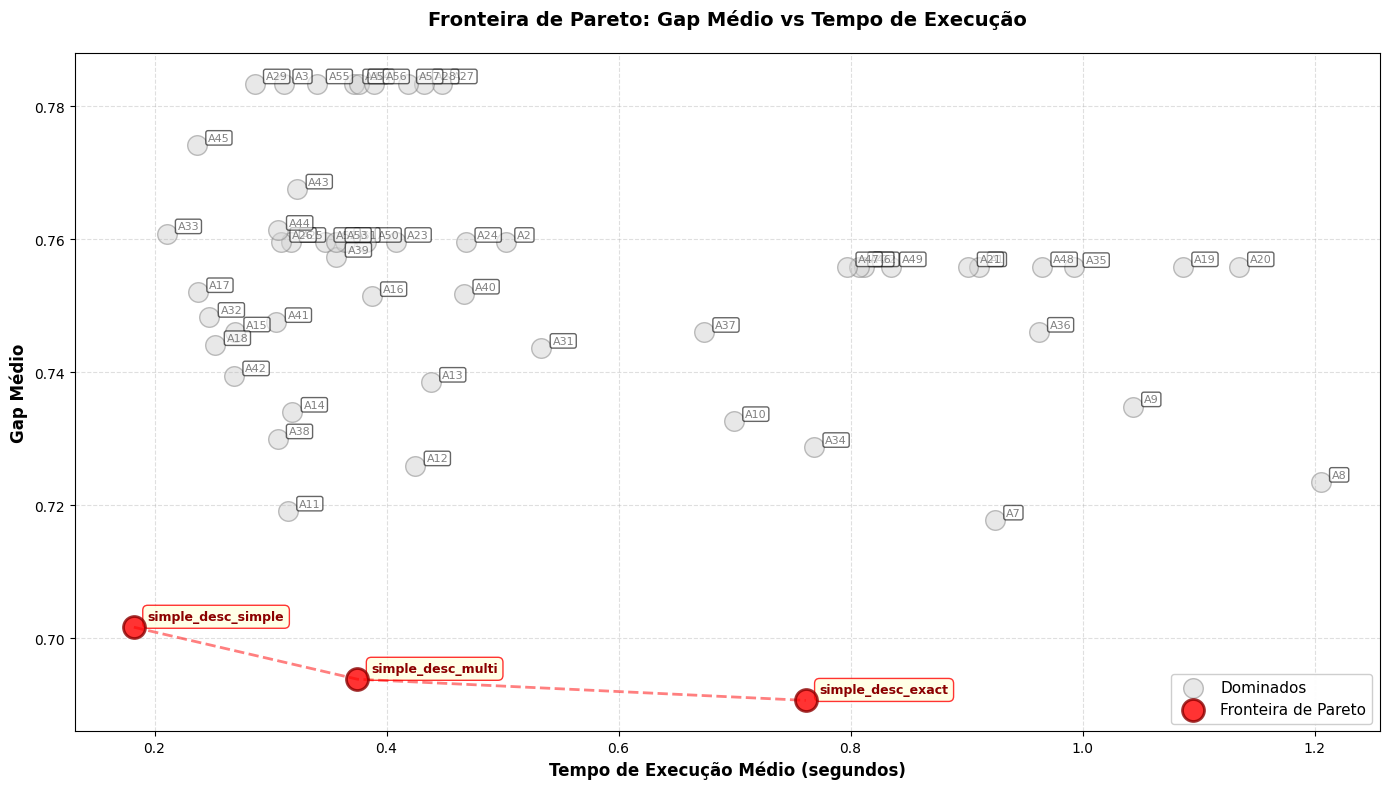


FRONTEIRA DE PARETO
Total de algoritmos: 57
Algoritmos na Fronteira: 3

Algoritmos Eficientes (Fronteira de Pareto):
id          algorithm  exec_time_mean_avg  gap_mean_avg
A4  simple_desc_exact            0.761319      0.690663
A5  simple_desc_multi            0.374917      0.693844
A6 simple_desc_simple            0.182187      0.701670


In [140]:
# ---------------------------------------------------------
# CÁLCULO DA FRONTEIRA DE PARETO
# Objetivos: Minimizar Gap Médio e Tempo de Execução
# ---------------------------------------------------------

def calcular_pareto(df, col_x, col_y):
    """
    Calcula a fronteira de Pareto para minimizar col_x e col_y
    Retorna índices dos pontos na fronteira
    """
    pareto_indices = []
    for i, row_i in df.iterrows():
        dominado = False
        for j, row_j in df.iterrows():
            if i != j:
                # row_j domina row_i se é melhor ou igual em ambas as dimensões
                # e estritamente melhor em pelo menos uma
                if (row_j[col_x] <= row_i[col_x] and row_j[col_y] <= row_i[col_y] and
                    (row_j[col_x] < row_i[col_x] or row_j[col_y] < row_i[col_y])):
                    dominado = True
                    break
        if not dominado:
            pareto_indices.append(i)
    return pareto_indices

# Calcula a fronteira de Pareto
pareto_idx = calcular_pareto(gap_summary, "exec_time_mean_avg", "gap_mean_avg")
gap_summary["is_pareto"] = gap_summary.index.isin(pareto_idx)

# ---------------------------------------------------------
# GRÁFICO: FRONTEIRA DE PARETO
# ---------------------------------------------------------

plt.figure(figsize=(14, 8))

# Separa pontos Pareto e dominados
df_pareto = gap_summary[gap_summary["is_pareto"]]
df_dominados = gap_summary[~gap_summary["is_pareto"]]

# Plot dos pontos dominados (cinza)
plt.scatter(df_dominados["exec_time_mean_avg"], df_dominados["gap_mean_avg"], 
            s=200, alpha=0.5, c='lightgray', edgecolors='gray', linewidth=1, label="Dominados")

# Plot dos pontos da Fronteira de Pareto (vermelho)
plt.scatter(df_pareto["exec_time_mean_avg"], df_pareto["gap_mean_avg"], 
            s=250, alpha=0.8, c='red', edgecolors='darkred', linewidth=2, label="Fronteira de Pareto", zorder=5)

# Desenha linha conectando os pontos da Fronteira de Pareto
df_pareto_sorted = df_pareto.sort_values("exec_time_mean_avg")
plt.plot(df_pareto_sorted["exec_time_mean_avg"], df_pareto_sorted["gap_mean_avg"], 
         'r--', alpha=0.5, linewidth=2, zorder=4)

# Adiciona rótulos com nomes dos algoritmos
for idx, row in gap_summary.iterrows():
    if row["is_pareto"]:
        # Para pontos na Fronteira: mostrar nome do algoritmo
        plt.annotate(
            row["algorithm"],
            (row["exec_time_mean_avg"], row["gap_mean_avg"]),
            textcoords="offset points",
            xytext=(10, 5),
            ha="left",
            fontsize=9,
            fontweight="bold",
            color="darkred",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8, edgecolor="red")
        )
    else:
        # Para pontos dominados: mostrar apenas o ID
        plt.annotate(
            row["id"],
            (row["exec_time_mean_avg"], row["gap_mean_avg"]),
            textcoords="offset points",
            xytext=(8, 3),
            ha="left",
            fontsize=8,
            color="gray",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6)
        )

# Configurações do gráfico
plt.xlabel("Tempo de Execução Médio (segundos)", fontsize=12, fontweight="bold")
plt.ylabel("Gap Médio", fontsize=12, fontweight="bold")
plt.title("Fronteira de Pareto: Gap Médio vs Tempo de Execução", fontsize=14, fontweight="bold", pad=20)

plt.legend(loc="lower right", fontsize=11, framealpha=0.95)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Imprime os algoritmos na Fronteira de Pareto
print("\n" + "="*60)
print("FRONTEIRA DE PARETO")
print("="*60)
print(f"Total de algoritmos: {len(gap_summary)}")
print(f"Algoritmos na Fronteira: {len(df_pareto)}")
print("\nAlgoritmos Eficientes (Fronteira de Pareto):")
print(df_pareto[["id", "algorithm", "exec_time_mean_avg", "gap_mean_avg"]].to_string(index=False))

In [141]:
algorithms_names = df_pareto["algorithm"].tolist()
algorithms_names

['simple_desc_exact', 'simple_desc_multi', 'simple_desc_simple']

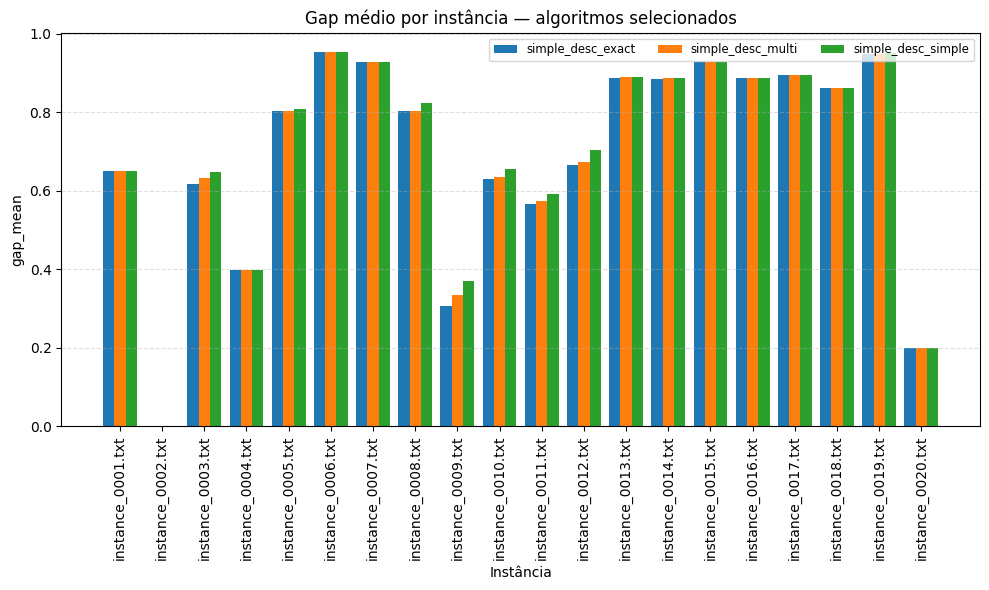

In [142]:
# ---------------------------------------------------------
# BARRAS AGRUPADAS POR INSTÂNCIA: gap_mean por algoritmo
# Eixo x: instâncias  — Eixo y: gap_mean — barras por algoritmo
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# Filtra algoritmos se a lista estiver disponível
if 'algorithms_names' in globals():
    algs = list(algorithms_names)
else:
    algs = sorted(df_resultados['algorithm'].unique())

df_plot = df_resultados[df_resultados['algorithm'].isin(algs)].copy()

# Pivot: index=instance, columns=algorithm, values=gap_mean (média se múltiplas medidas)
pivot = df_plot.pivot_table(index='instance', columns='algorithm', values='gap_mean', aggfunc='mean').fillna(0)
# Garante ordem das colunas conforme algs (se algum algoritmo não aparecer, será preenchido com 0)
pivot = pivot.reindex(columns=algs, fill_value=0)

# Tenta ordenar instâncias numericamente quando possível
try:
    inst_order = sorted(pivot.index, key=lambda x: int(x))
except Exception:
    inst_order = sorted(pivot.index)
pivot = pivot.reindex(inst_order)

n_instances = len(pivot)
n_algs = len(algs)
x = np.arange(n_instances)
width = 0.8 / max(1, n_algs)

plt.figure(figsize=(max(10, n_instances*0.3), 6))
for i, alg in enumerate(algs):
    ys = pivot[alg].values if alg in pivot.columns else np.zeros(n_instances)
    plt.bar(x + i*width - (n_algs-1)*width/2, ys, width, label=alg)

plt.xticks(x, pivot.index, rotation=90)
plt.xlabel('Instância')
plt.ylabel('gap_mean')
plt.title('Gap médio por instância — algoritmos selecionados')
plt.legend(ncol=min(4, n_algs), fontsize='small')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
